In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv(r"../outputs/twitter-data.csv")

In [5]:
# Convert 'timestamp' to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

In [6]:
# Add 'date' column for time series analysis
df['date'] = df['timestamp'].dt.date

In [7]:
# Create sentiment polarity column
df['sentiment_polarity'] = df['tweet message'].apply(lambda text: TextBlob(str(text)).sentiment.polarity)

In [8]:
# Classify sentiment
def get_sentiment_label(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'


In [9]:
df['sentiment'] = df['sentiment_polarity'].apply(get_sentiment_label)

In [10]:
df.to_csv(r"../outputs/twitter-data_.csv")

In [11]:
# 1. Summary statistics
print("Summary Statistics:\n")
print(df.describe(include='all'))

Summary Statistics:

       author         likes     comments                            timestamp  \
count     267    263.000000   263.000000                                  263   
unique      7           NaN          NaN                                  NaN   
top       ANI           NaN          NaN                                  NaN   
freq       40           NaN          NaN                                  NaN   
mean      NaN    846.817490    74.699620  2025-05-08 11:11:20.288973312+00:00   
min       NaN      0.000000     0.000000            2025-04-22 12:27:51+00:00   
25%       NaN     46.500000     3.000000            2025-05-01 01:12:17+00:00   
50%       NaN    249.000000     9.000000            2025-05-10 08:47:45+00:00   
75%       NaN    505.000000    28.000000     2025-05-15 17:20:12.500000+00:00   
max       NaN  23000.000000  8200.000000            2025-05-21 22:58:34+00:00   
std       NaN   2225.282834   520.407119                                  NaN   

      

In [12]:
# 2. Missing value analysis
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

author                0
likes                 4
comments              4
timestamp             4
country               0
URL                   4
query                 0
tweet message         4
date                  4
sentiment_polarity    0
sentiment             0
dtype: int64


In [13]:
# 3. Author-wise tweet counts
print("\nTop Authors by Tweet Count:\n")
print(df['author'].value_counts())


Top Authors by Tweet Count:

author
ANI              40
FirstPost        40
timesofindia     39
PTI              39
The Hindu        39
EconomicTimes    38
Sky News         32
Name: count, dtype: int64


Text(0.5, 1.0, 'Distribution of Likes')

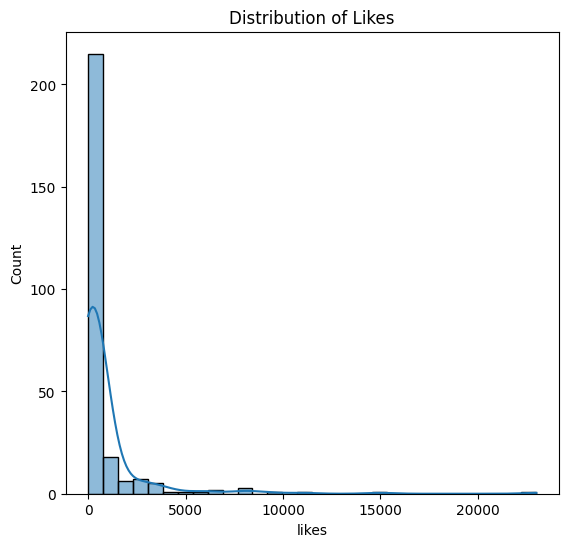

In [14]:

# 4. Distribution plots for likes and comments
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['likes'].dropna(), bins=30, kde=True)
plt.title('Distribution of Likes')

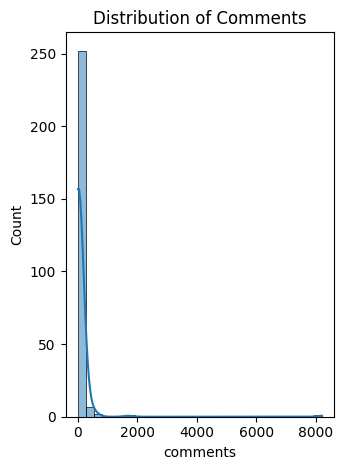

In [15]:
plt.subplot(1, 2, 2)
sns.histplot(df['comments'].dropna(), bins=30, kde=True)
plt.title('Distribution of Comments')
plt.tight_layout()
plt.show()

In [16]:
# 5. Time-series trend of tweets
tweets_per_day = df['date'].value_counts().sort_index()

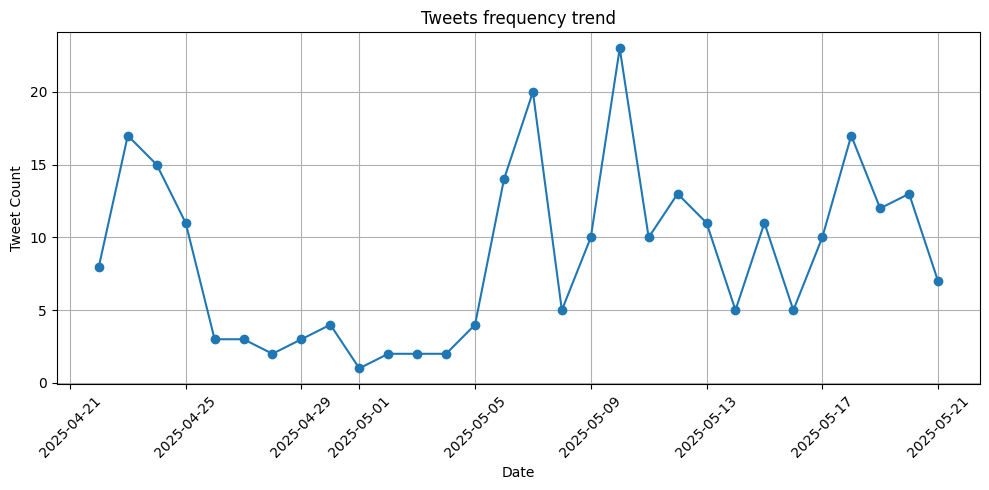

In [17]:

plt.figure(figsize=(10, 5))
tweets_per_day.plot(kind='line', marker='o')
plt.title('Tweets frequency trend')
plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Drop rows with missing tweet messages
df_sentiment = df.dropna(subset=['tweet message'])

In [19]:
# Sentiment Analysis using TextBlob
def get_sentiment_polarity(text):
    return TextBlob(text).sentiment.polarity

df_sentiment.loc[:, 'sentiment'] = df_sentiment['tweet message'].apply(get_sentiment_polarity)
df_sentiment.loc[:, 'sentiment_label'] = df_sentiment['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral')
)

country_engagement = df_sentiment.groupby('country')[['likes', 'comments']].sum().sort_values(by='likes', ascending=False)
print("\nCountry-wise Engagement:\n")
print(country_engagement)


Country-wise Engagement:

            likes  comments
country                    
India    180261.0   15070.0
UK        42452.0    4576.0


/tmp/ipykernel_2904/1313223047.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sentiment.loc[:, 'sentiment_label'] = df_sentiment['sentiment'].apply(



Country-wise Sentiment Distribution:

sentiment_label  Negative  Neutral  Positive
country                                     
India                  70       88        73
UK                     13       10         9


<Figure size 1000x600 with 0 Axes>

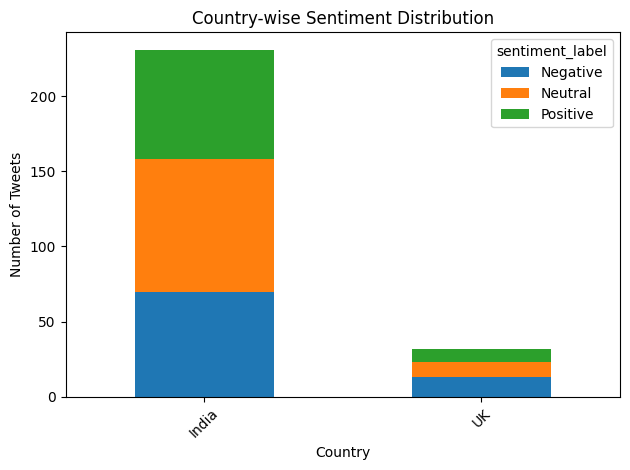

In [20]:
country_sentiment_counts = df_sentiment.groupby(['country', 'sentiment_label']).size().unstack(fill_value=0)
print("\nCountry-wise Sentiment Distribution:\n")
print(country_sentiment_counts)

# Optional Visualization
plt.figure(figsize=(10, 6))
country_sentiment_counts.plot(kind='bar', stacked=True)
plt.title("Country-wise Sentiment Distribution")
plt.xlabel("Country")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()